C:\Users\hp\AppData\Local\Temp\ipykernel_26208\3242993250.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM price", conn)


Epoch 1/25


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0476 
Epoch 2/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074 
Epoch 3/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 
Epoch 4/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058   
Epoch 5/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 
Epoch 6/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0051 
Epoch 7/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0048   
Epoch 8/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0050   
Epoch 9/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0048 
Epoch 10/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045 
Epoch 11/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045 
Epoch 12/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042 
Epoch 13/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041 
Epoch 14/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 
Epoch 15/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

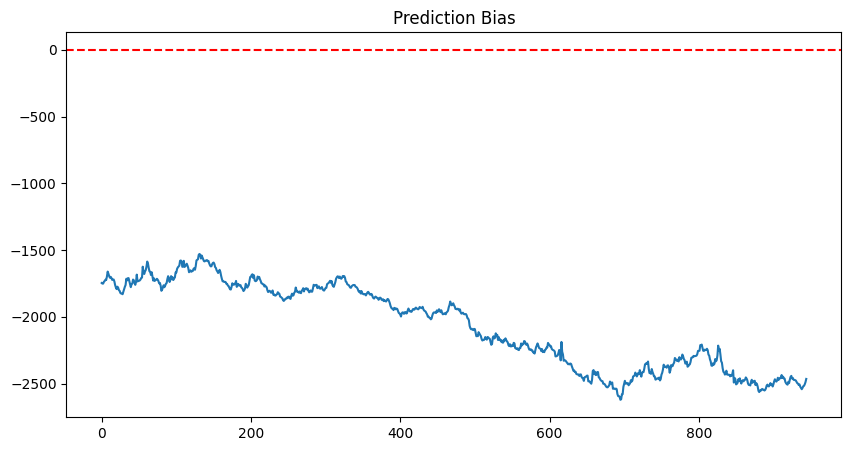

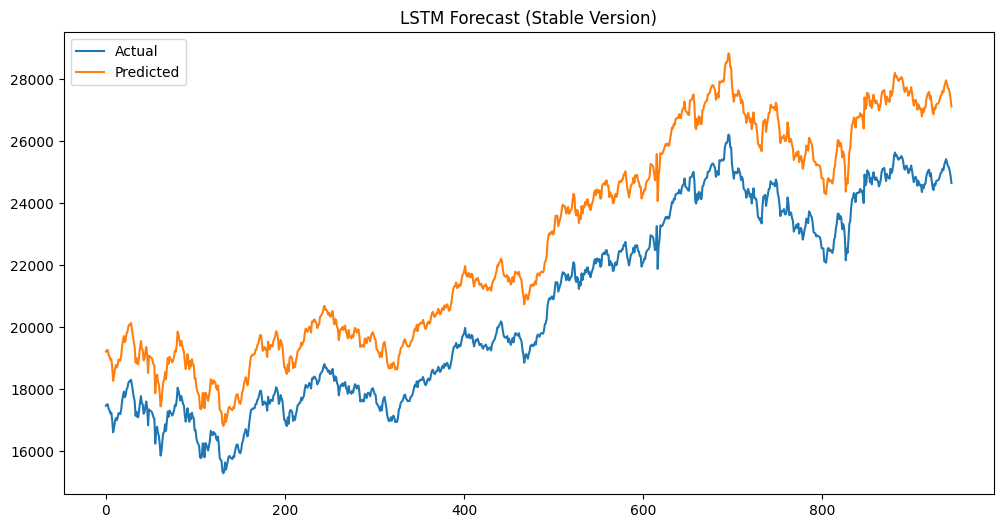

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Next Day Prediction: 27120.170587813856


In [23]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import pymysql
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ==========================================
# 2. LOAD DATA FROM MYSQL
# ==========================================
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="S108108w",
    database="nifty50"
)

df = pd.read_sql("SELECT * FROM price", conn)
conn.close()

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
df['Return'] = df['Closing Index Value'].pct_change()

df['MA10'] = df['Closing Index Value'].rolling(10).mean()
df['MA50'] = df['Closing Index Value'].rolling(50).mean()

df['Volatility'] = df['Return'].rolling(10).std()
df['Momentum'] = df['Closing Index Value'] - df['Closing Index Value'].shift(5)

df = df.dropna()

# ==========================================
# 4. PREPARE FEATURES
# ==========================================
features = ['Return', 'MA10', 'MA50', 'Volatility', 'Momentum']
data = df[features].values

# ==========================================
# 5. SCALE FEATURES (IMPORTANT)
# ==========================================
feature_scaler = MinMaxScaler()
data_scaled = feature_scaler.fit_transform(data)

# ==========================================
# 6. CREATE DATASET
# ==========================================
def create_dataset(data, time_step=2):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step][0])  # Return target only
    return np.array(X), np.array(y)

time_step = 2
X, y = create_dataset(data_scaled, time_step)

# ==========================================
# 7. TRAIN-TEST SPLIT (TIME BASED)
# ==========================================
train_size = int(len(X) * 0.7)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# ==========================================
# 8. BUILD LSTM MODEL
# ==========================================
model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(time_step, X.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# ==========================================
# 9. TRAIN MODEL
# ==========================================
model.fit(X_train, y_train, epochs=25, batch_size=16)

# ==========================================
# 10. PREDICT RETURNS
# ==========================================
pred_return = model.predict(X_test)

# 🔥 IMPORTANT: CLIP RETURNS TO AVOID EXPLOSION
pred_return = np.clip(pred_return, -0.1, 0.1)

# Debug check
print("Min return:", np.min(pred_return))
print("Max return:", np.max(pred_return))

# ==========================================
# 11. CONVERT RETURNS → PRICE (FIXED)
# ==========================================
actual_prices = df['Closing Index Value'].values

start_index = train_size + time_step
actual_test_prices = actual_prices[start_index:start_index + len(pred_return)]

pred_prices = []

for i in range(len(pred_return)):
    base_price = actual_test_prices[i]   # ✅ use actual price (NOT predicted)
    next_price = base_price * (1 + pred_return[i][0])
    pred_prices.append(next_price)

pred_prices = np.array(pred_prices)
actual_test_prices = np.array(actual_test_prices)

# ==========================================
# 12. CLEAN DATA (REMOVE INF/NAN)
# ==========================================
mask = np.isfinite(actual_test_prices) & np.isfinite(pred_prices)

actual_test_prices = actual_test_prices[mask]
pred_prices = pred_prices[mask]

# ==========================================
# 13. EVALUATION
# ==========================================
rmse = np.sqrt(mean_squared_error(actual_test_prices, pred_prices))
print("Test RMSE:", rmse)

# Direction Accuracy
actual_dir = np.sign(np.diff(actual_test_prices))
pred_dir = np.sign(np.diff(pred_prices))

direction_acc = np.mean(actual_dir == pred_dir)
print("Direction Accuracy:", direction_acc)

# ==========================================
# 14. BIAS ANALYSIS
# ==========================================
bias = actual_test_prices - pred_prices

print("Mean Bias:", np.mean(bias))

plt.figure(figsize=(10,5))
plt.plot(bias)
plt.axhline(0, color='red', linestyle='--')
plt.title("Prediction Bias")
plt.show()

# ==========================================
# 15. PLOT RESULTS
# ==========================================
plt.figure(figsize=(12,6))

plt.plot(actual_test_prices, label='Actual')
plt.plot(pred_prices, label='Predicted')

plt.legend()
plt.title("LSTM Forecast (Stable Version)")
plt.show()

# ==========================================
# 16. NEXT DAY FORECAST
# ==========================================
last_seq = data_scaled[-time_step:]
last_seq = last_seq.reshape(1, time_step, X.shape[2])

next_return = model.predict(last_seq)
next_return = np.clip(next_return, -0.1, 0.1)

next_price = actual_prices[-1] * (1 + next_return[0][0])

print("Next Day Prediction:", next_price)